In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import corner
df = pd.read_csv("all_features.csv")
df_acv = df[df['type'] == 'ACV']
#df_rot.to_csv("features_only_ROT.csv", index=False)

In [2]:
df_acv

,id_star,type,Period,FAP,Amplitud,Rcs,Stetsonk,Mean_variance,Autocor_length,Con,...,Eta_e,Mean,Q31,AndersonDarling,Gskew,StructureFunction_index_21,StructureFunction_index_31,StructureFunction_index_32,Pvar,ExcessVar
3606,92705248,ACV,2.156878,0.000000e+00,0.011496,0.075667,0.880651,0.000552,18,0.0,...,0.009114,13.459393,0.013814,1.0,-0.002103,1.877070,2.664996,1.425416,1.000000e+00,1.469366e-07
3607,309148260,ACV,13.718052,0.000000e+00,0.016719,0.256555,0.875080,0.000761,79,0.0,...,0.006332,14.351399,0.017307,1.0,-0.021531,1.952491,2.870382,1.480612,1.000000e+00,2.580122e-07
3608,358467700,ACV,1.945394,4.994292e-197,0.023456,0.102348,0.783158,0.000966,12,0.0,...,0.017490,13.674782,0.016761,1.0,-0.000672,1.806485,2.474699,1.403148,1.000000e+00,7.461588e-07
3609,392761412,ACV,2.156878,0.000000e+00,0.009296,0.057053,0.886303,0.000478,18,0.0,...,0.007115,13.166873,0.011912,1.0,0.001057,1.798654,2.472253,1.391367,1.000000e+00,1.028342e-07
3610,41259805,ACV,1.712627,3.084161e-272,0.015901,0.083574,0.830293,0.000731,12,0.0,...,0.014840,13.221255,0.015246,1.0,-0.005307,1.903403,2.760751,1.462332,1.000000e+00,4.030493e-07
3611,410451777,ACV,1.224824,3.030176e-242,0.007234,0.070875,0.824839,0.000320,14,0.0,...,0.029601,13.164343,0.006091,1.0,-0.003188,1.813753,2.529792,1.420488,4.967157e-07,-2.370186e-08
3612,238869272,ACV,4.131103,0.000000e+00,0.011747,0.146624,0.894334,0.000580,34,0.0,...,0.003133,13.684092,0.015163,1.0,0.004192,1.930410,2.811884,1.459710,1.000000e+00,1.486010e-07
3613,364424408,ACV,1.556943,0.000000e+00,0.010013,0.054187,0.888437,0.000467,13,0.0,...,0.016530,14.388242,0.012016,1.0,-0.009424,1.854008,2.615583,1.415644,4.947782e-20,-1.071210e-07
3614,350146577,ACV,1.838316,0.000000e+00,0.051698,0.051024,0.896485,0.002755,16,0.0,...,0.011594,12.763149,0.064886,1.0,-0.034189,1.838168,2.571467,1.406605,1.000000e+00,7.492723e-06
3615,355650641,ACV,1.277124,0.000000e+00,0.015419,0.036234,0.900082,0.000941,12,0.0,...,0.014050,11.601583,0.021916,1.0,0.002541,1.730280,2.325693,1.376002,1.000000e+00,8.463482e-07


In [3]:
## creating a corner plot for ACV
features_list = [
    'Period',
    'FAP',
    'Amplitud',
    'Rcs',
    'Stetsonk',
    'Mean_variance',
    'Autocor_length'
    #'Con',
    # 'Eta_e',
    # 'Mean',
    # 'Q31',
    # 'AndersonDarling',
    # 'Gskew',
    # 'StructureFunction_index_21',
    # 'StructureFunction_index_31',
    # 'StructureFunction_index_32',
    # 'Pvar',
    # 'ExcessVar'
]

# we verify if the comun exist 
for col in features_list:
    if col not in df_acv.columns:
        raise KeyError(f"column '{col}' does not exist.")

In [4]:
data = df[features_list].dropna().values

#we use labels
labels = [
    r'Period [d]',                     # Period
    r'FAP',                            # False Alarm Probability
    r'Amplitude [mag]',                # Amplitud
    r'Rcs',                            # Range of cumulative sum
    r'Stetson $K$',                    # Stetson K variability index
    r'Mean / Variance',                # Mean_variance
    r'Autocorrelation length'        # Autocor_length
    #r'Con',                            # Consecutive out-of-2σ
    # r'$\eta_e$',                       # Eta_e (η_e)
    # r'Mean magnitude',                 # Mean
    # r'Q31',                            # Interquartile range
    # r'Anderson–Darling',               # AndersonDarling
    # r'Gskew',                          # Galton skewness
    # r'SF index 2,1',                   # StructureFunction_index_21
    # r'SF index 3,1',                   # StructureFunction_index_31
    # r'SF index 3,2',                   # StructureFunction_index_32
    # r'Pvar',                           # Variability probability
    # r'Excess variance'                 # ExcessVar
]

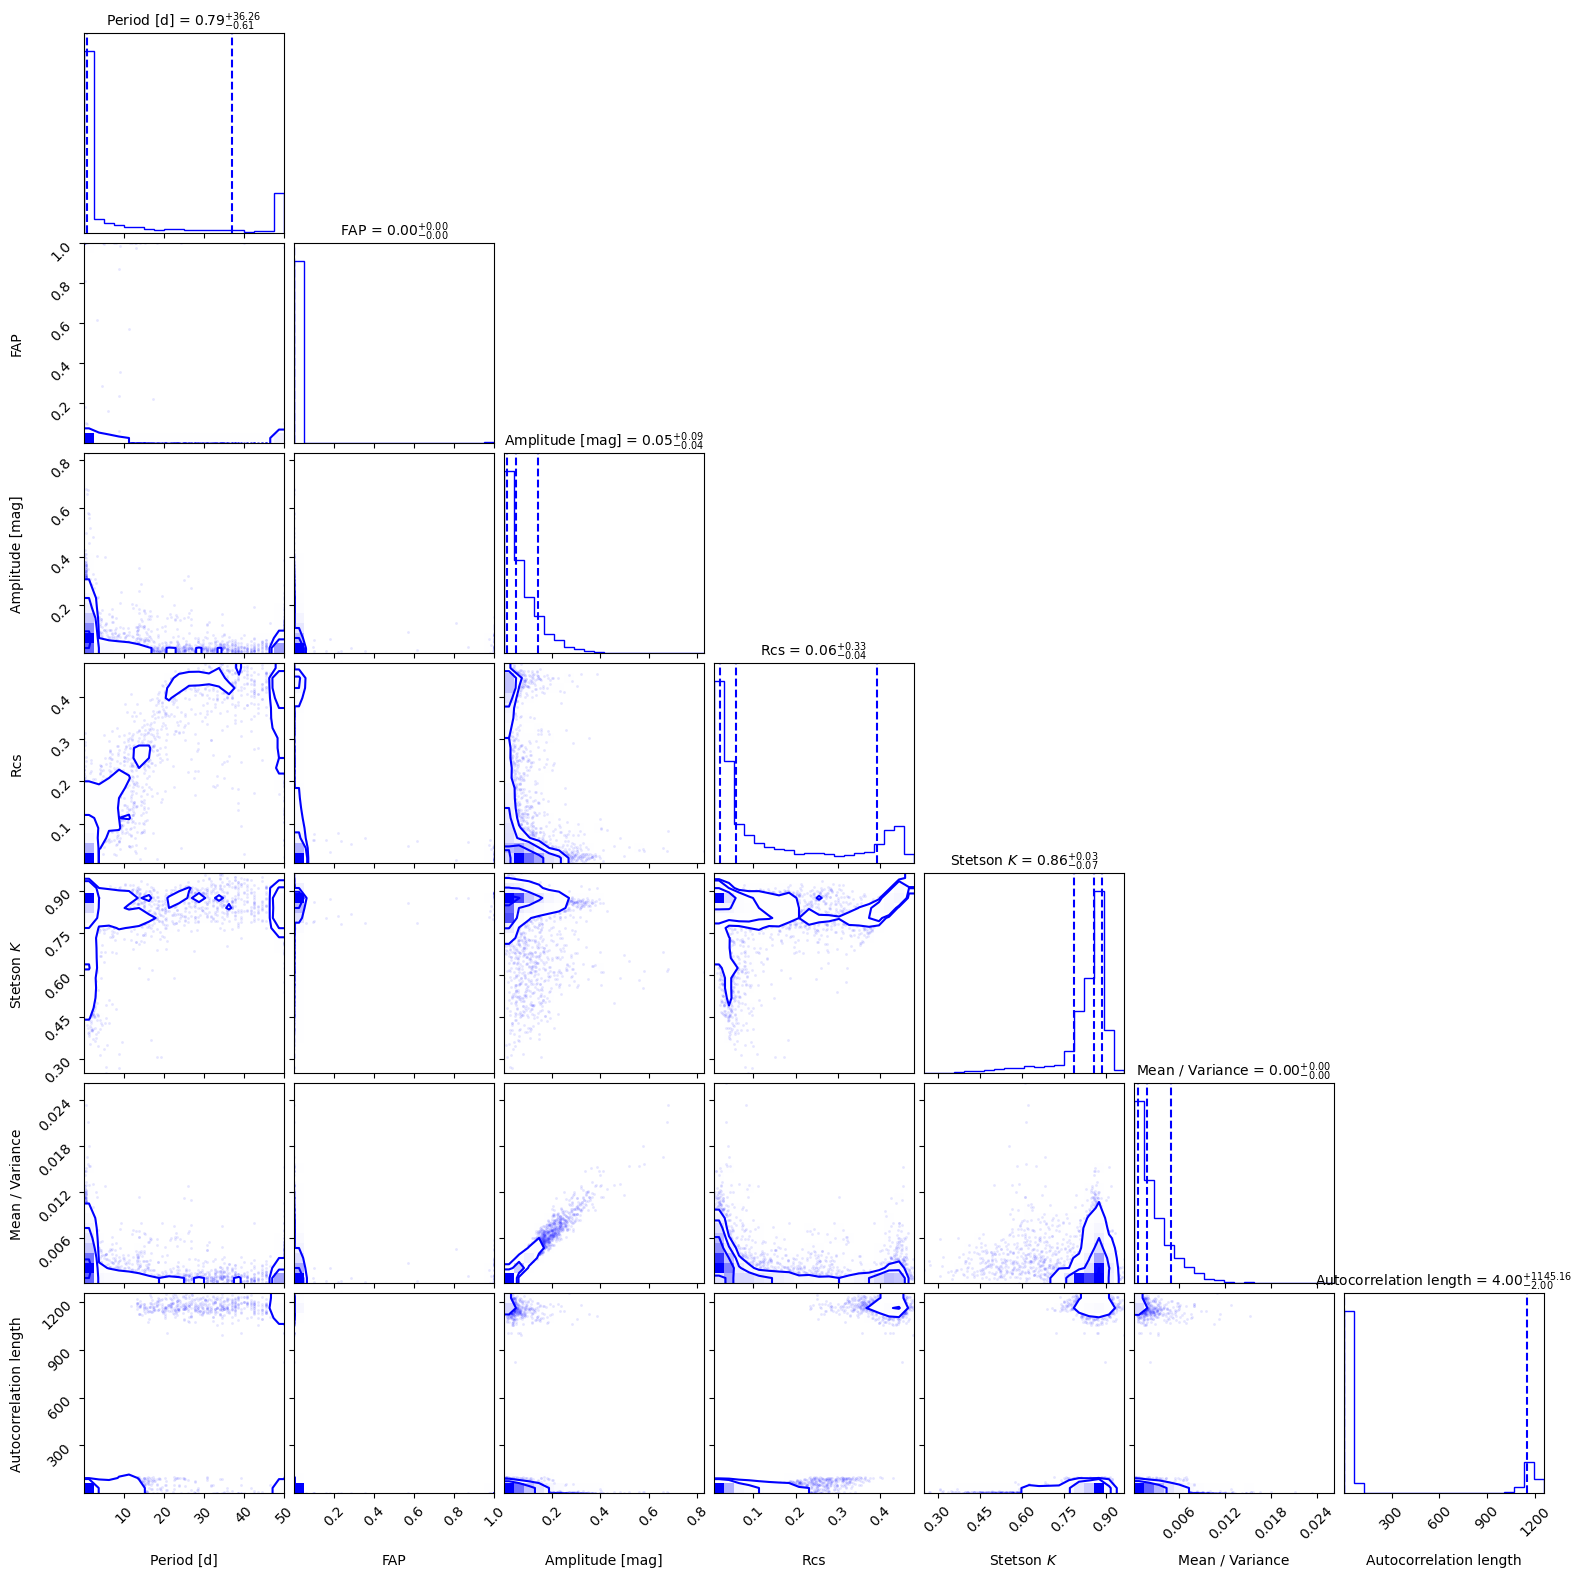

In [5]:
figure = corner.corner(data, labels=labels,
                       quantiles=[0.16, 0.5, 0.84],   # muestra los percentiles 16, 50, 84
                       show_titles=True,              # muestra el título en cada subplot
                       title_kwargs={"fontsize": 10},
                       color='blue',                  # color de los contornos
                       hist_kwargs={'density': True}) # normaliza los histogramas
plt.savefig("corner_plot.pdf", dpi=300, bbox_inches='tight')
